In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

In [91]:
data = pd.read_csv(filepath_or_buffer='bank_data.csv', sep=";", header=0)
df = data.copy()
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Предобработка

In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


**1. Проверим датасет на наличие пропусков.**

In [93]:
for colum_name in df.columns:
    print(f'В столбце: "{colum_name}", кол-во пропусков = {df[colum_name].isnull().sum()}')

В столбце: "age", кол-во пропусков = 0
В столбце: "job", кол-во пропусков = 0
В столбце: "marital", кол-во пропусков = 0
В столбце: "education", кол-во пропусков = 0
В столбце: "default", кол-во пропусков = 0
В столбце: "balance", кол-во пропусков = 0
В столбце: "housing", кол-во пропусков = 0
В столбце: "loan", кол-во пропусков = 0
В столбце: "contact", кол-во пропусков = 0
В столбце: "day", кол-во пропусков = 0
В столбце: "month", кол-во пропусков = 0
В столбце: "duration", кол-во пропусков = 0
В столбце: "campaign", кол-во пропусков = 0
В столбце: "pdays", кол-во пропусков = 0
В столбце: "previous", кол-во пропусков = 0
В столбце: "poutcome", кол-во пропусков = 0
В столбце: "y", кол-во пропусков = 0


**2. Проверим датасет на дубликаты.**

In [94]:
df.duplicated().sum() # дубликатов нет

np.int64(0)

**3. Посмотрим на скрытые пропуски unknown**

In [95]:
cols_with_unknown=[]
for col in df.columns:
    if 'unknown' in df[col].unique():
        cols_with_unknown.append(col)
        print(f'Признак {col} содержит скрытые пропуски с процентным соотношением = {round(len(df[df[col]=='unknown'])/len(df)*100,3)} %')

Признак job содержит скрытые пропуски с процентным соотношением = 0.637 %
Признак education содержит скрытые пропуски с процентным соотношением = 4.107 %
Признак contact содержит скрытые пропуски с процентным соотношением = 28.798 %
Признак poutcome содержит скрытые пропуски с процентным соотношением = 81.748 %


В признаках contact и contact достаточно много пропусков. Но тут надо учитывать смысл этих признаков:
- contact описывает способ связи с клиентом (стационарный или мобильный телефон), поэтому unknown это, скорее всего, утерянная информация или запись о старых клиентах, когда не записывались данные о методе связи, поэтому оставим это как категорию
- poutcome показывает, какой результат маркетинга был в прошлый раз для этого клиента - 82% клиентов не участвовали в предыдущей кампании, поэтому это не пропуск, а ценная информация - что мы обрабатываем клиента впервые, поэтому тоже оставим

В остальных же признаках процент unknown слишком мал, поэтому можем оставить.

**4. Для временного анализа приведем month к числовому виду**

In [96]:
df['month'].unique()

<StringArray>
['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan', 'feb', 'mar', 'apr',
 'sep']
Length: 12, dtype: str

In [97]:
df['month_num']=df['month'].map({'may':5, 'jun':6, 'jul':7, 'aug':8, 'oct':10, 'nov':11, 'dec':12, 'jan':1, 'feb':2, 'mar':3, 'apr':4, 'sep':9})

### Визуализация данных

In [98]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous,month_num
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323,6.144655
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441,2.408034
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,1.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000,5.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000,6.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000,8.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,12.000000


<Axes: title={'center': 'Распределение людей по работе'}, xlabel='job'>

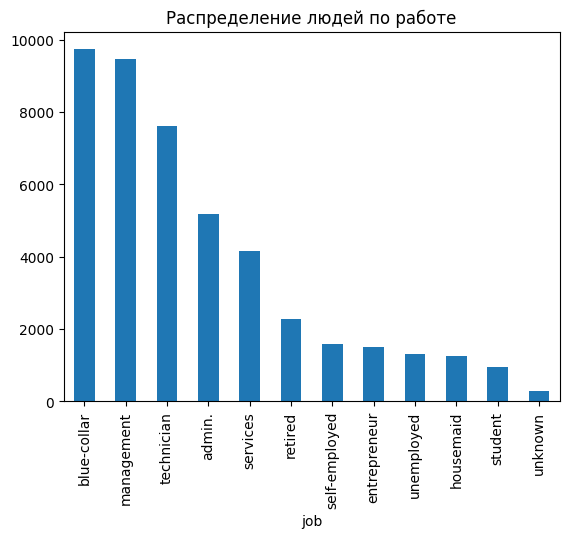

In [99]:
df['job'].value_counts().plot(kind='bar', title='Распределение людей по работе')

<Axes: title={'center': 'Распределение среднего и медианного баланса по работе'}, xlabel='job', ylabel='value (EUR)'>

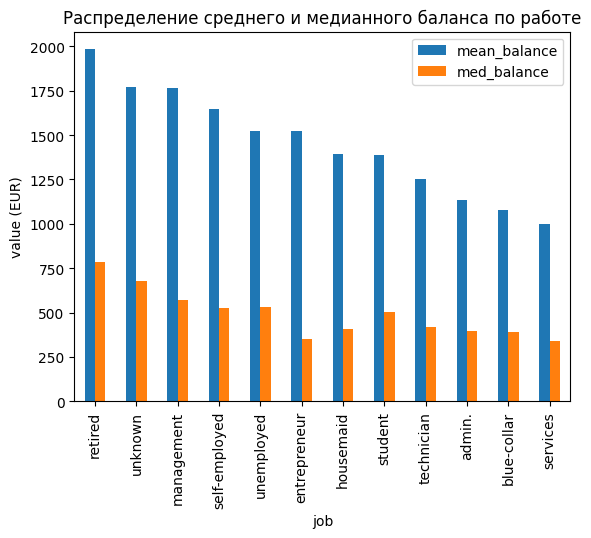

In [100]:
df.groupby(['job']).agg(
    mean_balance=('balance', 'mean'),
    med_balance=('balance', 'median')
    ) \
    .sort_values(by='mean_balance', ascending=False) \
    .plot(kind='bar', ylabel='value (EUR)', title='Распределение среднего и медианного баланса по работе')

<Axes: title={'center': 'Распределение людей по семейному положению'}>

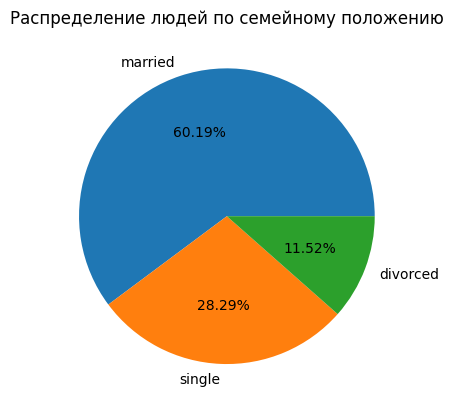

In [101]:
df['marital'].value_counts().plot(kind='pie', autopct=lambda x:'{:.2f}%'.format(x), ylabel='', title='Распределение людей по семейному положению') # https://stackoverflow.com/questions/6170246/how-do-i-use-matplotlib-autopct#:~:text=plt.pie(values%2C%20labels%3Dlabels%2C%20autopct%3Dlambda%20p%20%3A%20%27%7B%3A.2f%7D%25%20%20(%7B%3A%2C.0f%7D)%27.format(p%2Cp%20*%20sum(values)/100))

<Axes: title={'center': 'Распределение людей по уровню образования'}>

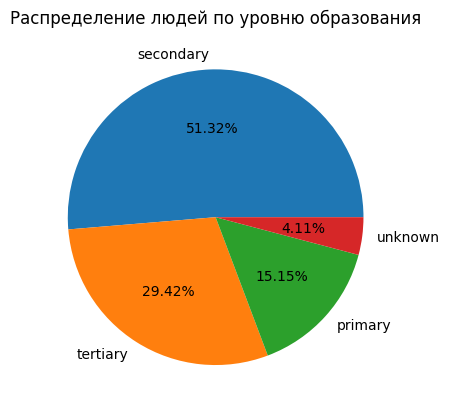

In [102]:
df['education'].value_counts().plot(kind='pie', autopct=lambda x:'{:.2f}%'.format(x), ylabel='', title='Распределение людей по уровню образования')

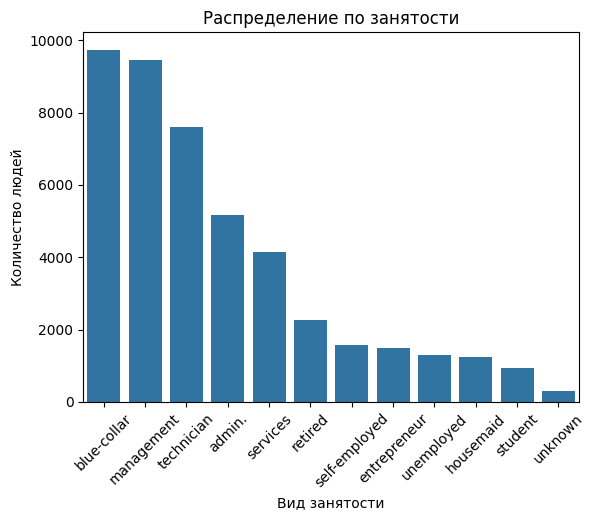

In [103]:
sns.barplot(x=df['job'].value_counts().index, y=df['job'].value_counts().values)
plt.title('Распределение по занятости')
plt.xticks(rotation=45)
plt.xlabel('Вид занятости')
plt.ylabel('Количество людей')
plt.show()

<Axes: title={'center': 'Зависимость ЗП от образования'}, xlabel='education', ylabel='ЗП (EUR)'>

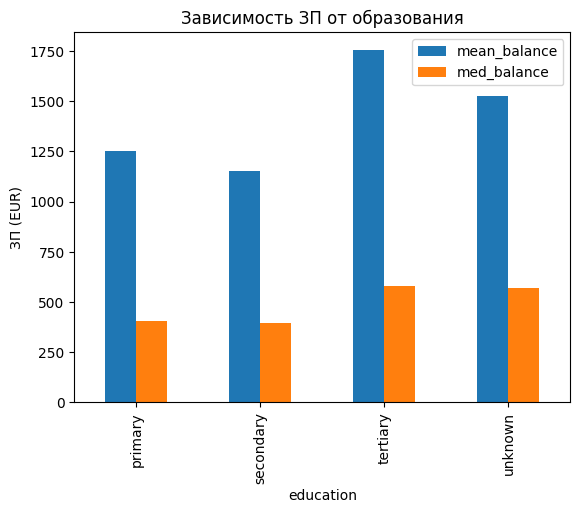

In [104]:
df.groupby(['education']).agg(
    mean_balance=('balance', 'mean'),
    med_balance=('balance', 'median')
).plot(kind='bar', ylabel='ЗП (EUR)', title='Зависимость ЗП от образования')

<Axes: title={'center': 'Распределение наличия просрочки по кредитке у клиентов'}>

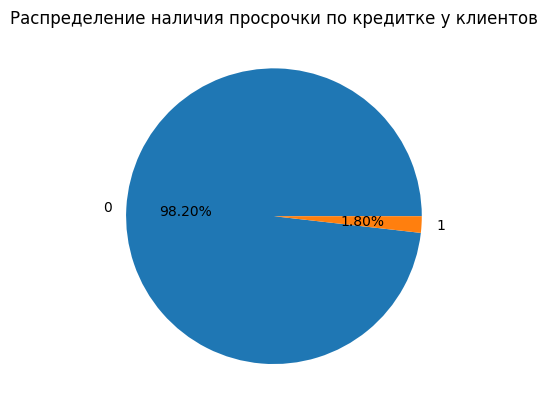

In [105]:
df['is_default'] = df['default'].map({
    'yes': 1,
    'no': 0   
})
df.drop(columns=['default'])
df['is_default'].value_counts().plot(kind='pie', autopct=lambda x:'{:.2f}%'.format(x), ylabel='', title='Распределение наличия просрочки по кредитке у клиентов', labels={'0': 'no', '1': 'yes'})

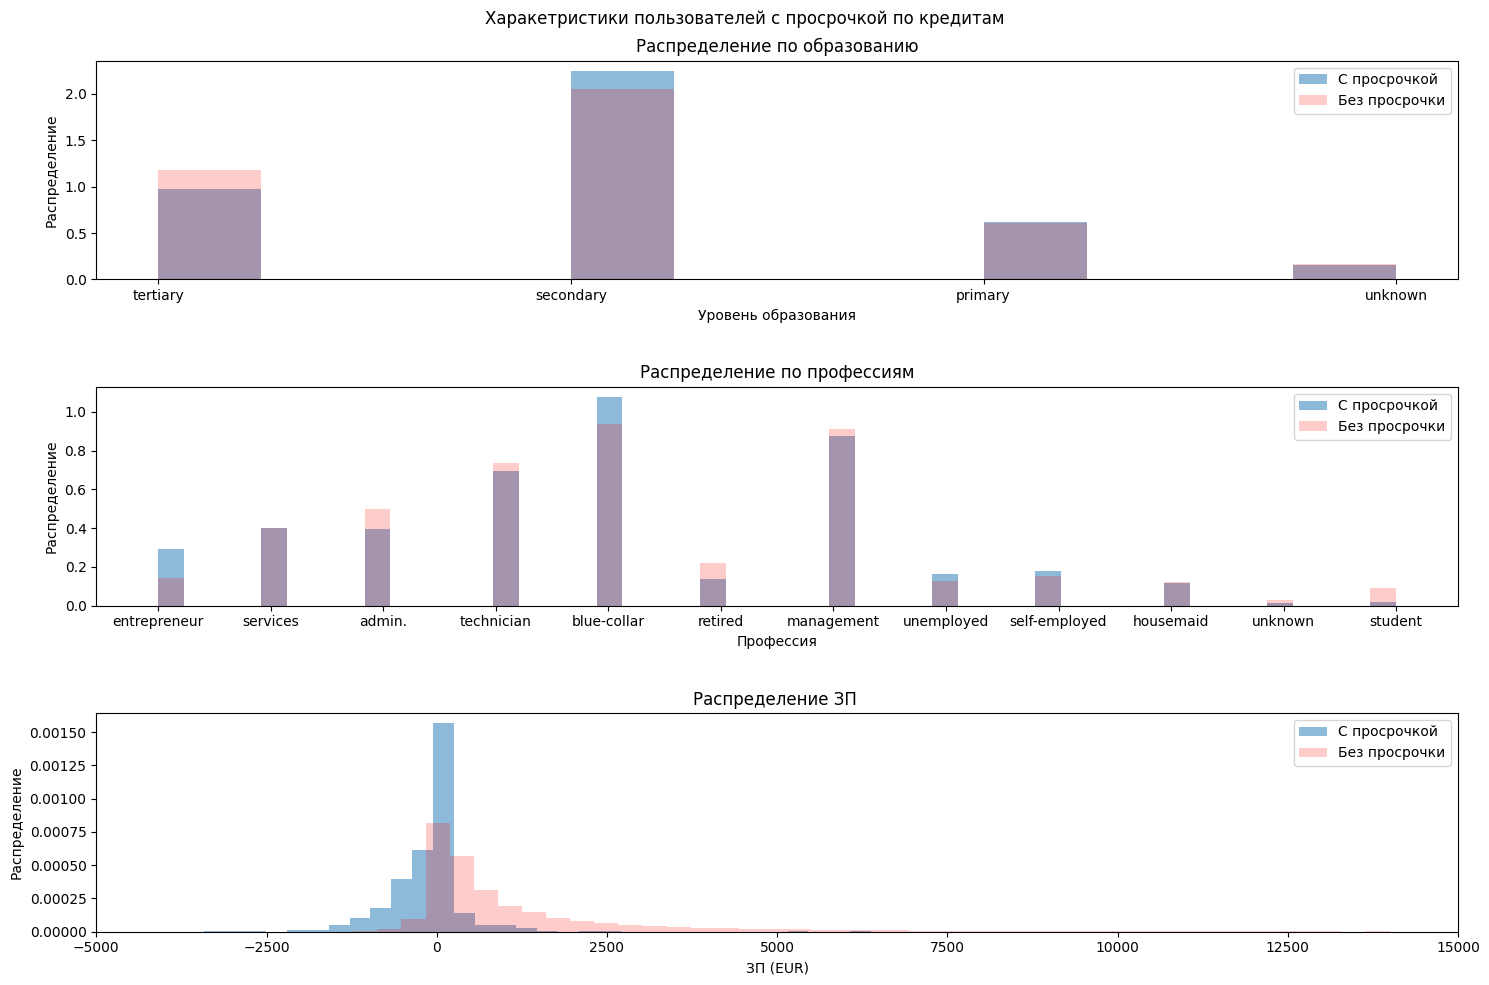

In [106]:
edudef = df[df['is_default'] == 1].groupby('education')['balance'].count()
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10))

ax1.hist(df[df['is_default'] == 1]['education'], alpha=0.5, bins=12, density=True, label='С просрочкой')
ax1.hist(df[df['is_default'] == 0]['education'], alpha=0.2, bins=12, density=True, color='red', label='Без просрочки')
ax1.legend()
ax1.set_title('Распределение по образованию')
ax1.set_xlabel('Уровень образования')
ax1.set_ylabel('Распределение')

ax2.hist(df[df['is_default'] == 1]['job'], alpha=0.5, bins=48, density=True, label='С просрочкой')
ax2.hist(df[df['is_default'] == 0]['job'], alpha=0.2, bins=48, density=True, color='red', label='Без просрочки')
ax2.legend()
ax2.set_title('Распределение по профессиям')
ax2.set_xlabel('Профессия')
ax2.set_ylabel('Распределение')

ax3.hist(df[df['is_default'] == 1]['balance'], alpha=0.5, bins=80, density=True, label='С просрочкой')
ax3.hist(df[df['is_default'] == 0]['balance'], alpha=0.2, bins=300, color='red', density=True, label='Без просрочки')
ax3.set_xlim((-5000, 15000))
ax3.legend()
ax3.set_title('Распределение ЗП ')
ax3.set_xlabel('ЗП (EUR)')
ax3.set_ylabel('Распределение')

fig.suptitle('Харакетристики пользователей с просрочкой по кредитам')

plt.tight_layout(h_pad=3)
plt.show()

**Анализ целевой переменной**

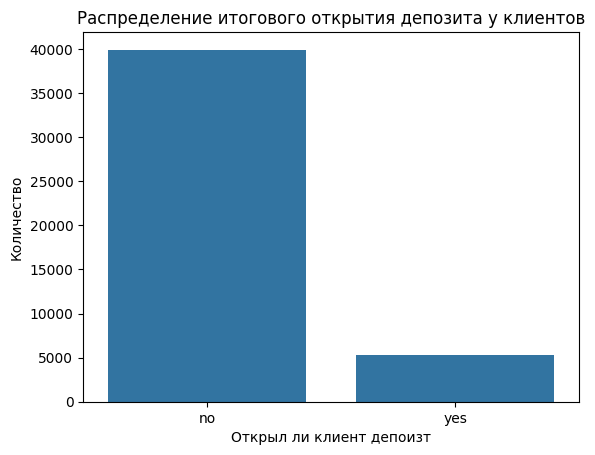

In [107]:
sns.barplot(x=df['y'].value_counts().index, y=df['y'].value_counts().values)
plt.title('Распределение итогового открытия депозита у клиентов')
plt.xlabel('Открыл ли клиент депоизт')
plt.ylabel('Количество')
plt.show()

In [108]:
# также для удобства дальнейшего анализа переведем в числовой вид
df['is_deposit'] = df['y'].map({
    'yes': 1,
    'no': 0   
})
df.drop(columns=['y'])

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,month_num,is_default,is_deposit
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,5,0,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,5,0,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,5,0,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,5,0,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,11,0,1
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,11,0,1
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,11,0,1
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,11,0,0


По графику выше (распределение целевой метрики) видно, что наши классы несбалансированы - только 12% людей открыли депозит. Это надо будет учитывать при дальнейшем анализе и выдвижении гипотез

Некоторые выводы

1. Age — возраст
    1. Возраст клиентов в датасете в среднем 41 год — наиболее финансово активное население, что логично
    2. Минимальный возраст — 18 лет, вероятно связано с юр. органичениями
2. Job — категория рабочей деятельности 
    1. ("admin." (администратор, опечатка), "unknown" (неизвестна), "unemployed" (не трудоустроен), "management" (менеджер), "housemaid" (горничная), "entrepreneur" (предприниматель), "student" (студент), "blue-collar" (["синие воротнички"](https://ru.wikipedia.org/wiki/%D0%A1%D0%B8%D0%BD%D0%B8%D0%B9_%D0%B2%D0%BE%D1%80%D0%BE%D1%82%D0%BD%D0%B8%D1%87%D0%BE%D0%BA), рабочий класс ), "self-employed" (самозанятые), "retired" (пенсионеры), "technician" (специалист-технарь), "services" (сфера услуг)) 
    2. В этой переменной есть неизвестная "unknown", заменяю на np.nan
    3. Самые популярные специальности "синий воротничок", технари, менеджеры, администраторы и сфера услуг. 
        2 тысячи человек — пенсионеры
        по 1,5к — самозанятых и предпринемателей
        порядка тысячи человек не трудоустроены, столько же студентов и домработниц
        Ну и люди с неизвестной деятельностью
    4. Интересно посмотреть еще и распределение среднего баланса по категориям:
        Самый большой ср. баланс у пенсионеров — около 2к евро
        Выбивается статус "unkown" — очень высокая медиана и среднее ЗП (возможно, ребята занимаются какой-либо нелегальной деятельностью и т.д.)
        Далее идут менеджеры, самозанятые, нетрудоустроеные (вероятно, находятся на обеспечении / сдают квартиры и тд, поэтому баланс такой большой) и предпринематели. Для предпринемателей интересно заметить, что медианный баланс значительно ниже, чем средний — логично, кто-то успешен, а кто-то нет
        Далее идут студенты и представители среднего класса (домработницы, технари, администраторы, синие воротнички и работники сферы услуг)
3. Marital — семейное положение
    1. Женат (married), Раведен (divorced), Одинок (single). Тут нет никаких 'unknown' и пропусков — это радует
    2. Опять же инетересно посмотреть в разрезе других фичей (работа, возраст)
4. Education — образование
    1. Тут опять же есть unknown(Неизвестно), secondary (Среднее образование (Школа)), tertiary (высшее образование, в португалии к нему относятся универы, колледжи и проф. училища), primary (Начальное образование, 1-4 класс)
    2. Интересно посмотреть как образование влияет на средний счет на балансе
        Интересно, что среднее образование не дает прироста к среднему балансу относительно первичного
        Высшее образование дает значительный прирост к ЗП относительно среднего и первичного образования
        В категории unknown ЗП сравнима с высшим образованием
5. Default — Наличие просрочки по кредиту
    1. Фича на самом деле бинарная, но в датасете дана в формате yes/no, сразу маппим в бинарное числовое представление is_default
    2. Посмотрим, как наличие этого флага влияет на среднюю/медиану ЗП
        Тут же поясню, почему мне всегда интересено влияние фичи на баланс. Наш таргет (NSM РК) — открытие депозитного счета, который непосредственно связан с наличием средств на балансе, так что баланс выступает в роли прокси к целевой метрике
        
        Просрочка по кредиту никак не связана с образованием
        Среди студентов, администраторов и пенсионеров просрочек меньше — такие люди значительно реже берут кредиты
        У предпринемателей, самозанятых, "синих воротничков" и нетрудоустроенных людей просрочек больше: предпринематели и некоторые самозанятые чаще лезут в кредитование, нетрудоустроенные и синие воротнички возможно берут чаще кредиты и не могут их закрыть в силу жизненных сложностей и потребностей больше ЗП
6. Balance — Средний годовой баланс
    1. В балансе интересно смотреть не среднее, а скорее медиану (иначе получится среднее по больнице). В районе 450 EU (согласно метаданным)
    2. Смотрим в разрезе других метрик в другом пункте, основная прокси к депозитному счету 
7. Housing — Есть кредит на дом или нет (бинарная метрика)
8. Loan — Есть кредит под личные нужды
9. Contact — тип маркетинговый коммуникации
10. Day of week — день недели, когда прошла последняя маркетинговая коммуникация
11. Month — последний месяц, когда прошла последняя маркетинговая коммуникация
12. Duration (длительность) — длительность последнего диалога по маркетинговой коммуникации. Важное замечание: этот атрибут сильно влияет на целевой выходной параметр (например, если duration=0, то y='no'). Однако длительность неизвестна до совершения звонка. Кроме того, после завершения звонка значение y становится очевидным. Таким образом, этот входной параметр следует включать только для целей сравнительного анализа и следует отбросить, если цель состоит в создании реалистичной прогностической модели.
13. Сampaign (кампания) — Количество контактов в рамках этой маркетинговой коммуникации на клиента
14. pdays (число дней) — Количество дней, прошедших с момента последнего контакта с клиентом в рамках предыдущей кампании (число; -1 означает, что с клиентом ранее не связывались).
15. previous — число контактов, которые проводили с клиентом до этой маркетинговой кампании
16. poutcome — утилизировался ли клиент от прошлых маркетинговых коммуникаций categorical: 'failure','nonexistent','success'
17. y (целевая метрика) — оформил ли клиент срочный депозит?

## Распределения признаков относительно целевой переменной

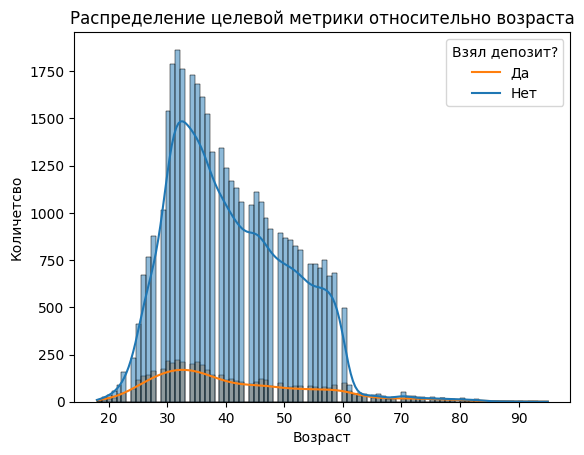

In [31]:
sns.histplot(data=df, x='age', hue='y', kde=True)
plt.title('Распределение целевой метрики относительно возраста')
plt.xlabel('Возраст')
plt.ylabel('Количетсво')
plt.legend(title='Взял депозит?', labels=['Да','Нет'])
plt.show()

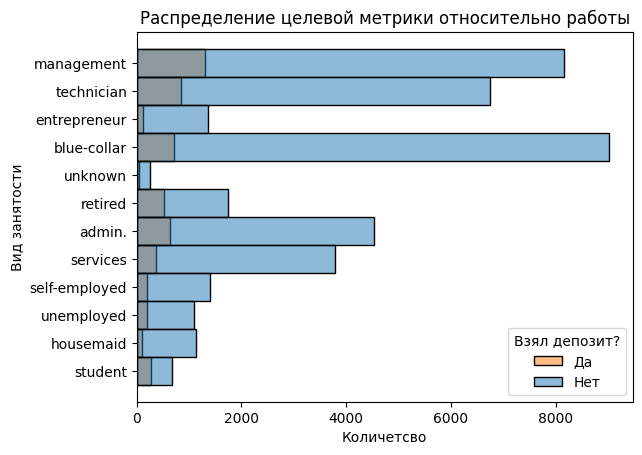

In [64]:
sns.histplot(data=df, y='job', hue='y')
plt.title('Распределение целевой метрики относительно работы')
plt.xlabel('Количетсво')
plt.ylabel('Вид занятости')
plt.legend(title='Взял депозит?', labels=['Да','Нет'])
plt.show()

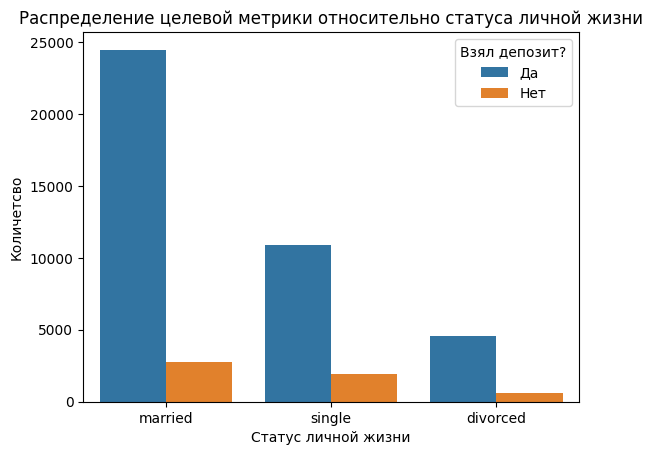

In [45]:
sns.countplot(data=df, x='marital', hue='y')
plt.title('Распределение целевой метрики относительно статуса личной жизни')
plt.xlabel('Статус личной жизни')
plt.ylabel('Количетсво')
plt.legend(title='Взял депозит?', labels=['Да','Нет'])
plt.show()

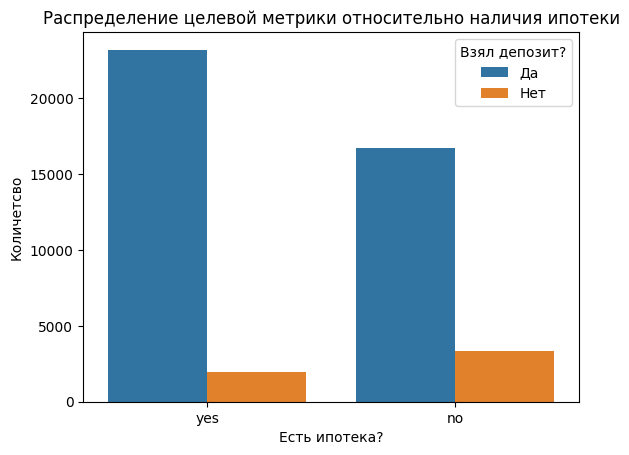

In [69]:
sns.countplot(data=df, x='housing', hue='y')
plt.title('Распределение целевой метрики относительно наличия ипотеки')
plt.xlabel('Есть ипотека?')
plt.ylabel('Количетсво')
plt.legend(title='Взял депозит?', labels=['Да','Нет'])
plt.show()

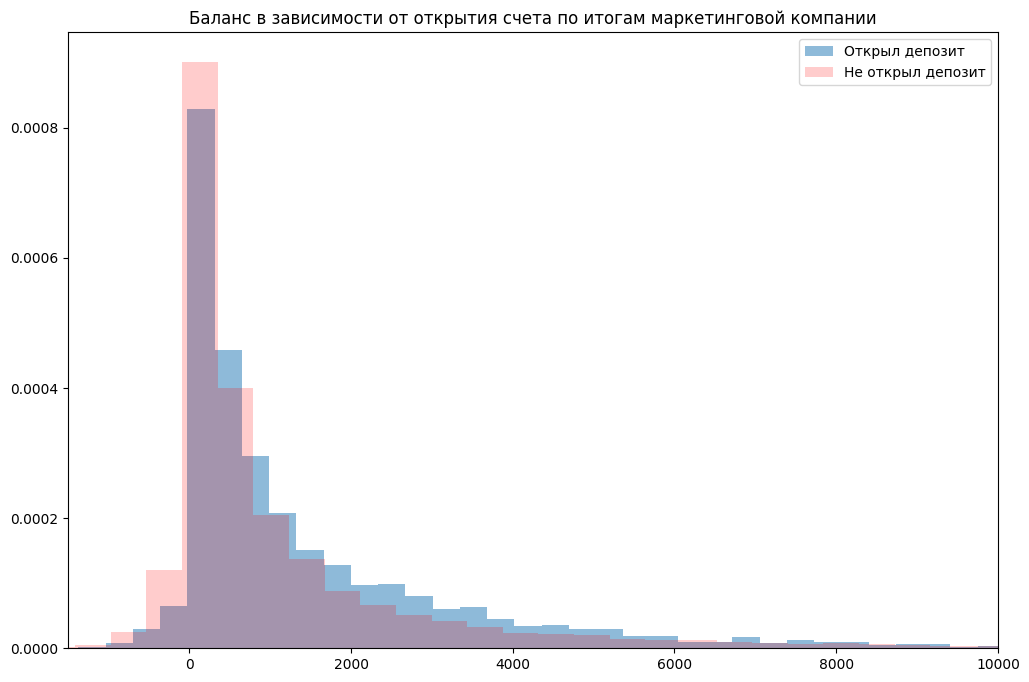

In [108]:
plt.figure(figsize=(12, 8))
plt.hist(df[df['y'] == 'yes']['balance'], bins=250, alpha=0.5, density=True, label='Открыл депозит')
plt.hist(df[df['y'] == 'no']['balance'], bins=250, alpha=0.2, density=True, color='red', label='Не открыл депозит')
plt.xlim((-1500, 10000))
plt.legend()
plt.title('Баланс в зависимости от открытия счета по итогам маркетинговой компании')
plt.show()

На самом деле смотреть просто на распределения относительно каждого признака нелогично - ведь мы смотрим на абсолютные значения: если белых воротничков намного больше в принципе в датасете, то и их количество, кто взял депозит, тоже будет большим, но если смотреть в относительных числах, то конверсия может быть маленькой. Надо смотреть соотношения по целевой колонке внутри каждой категории признака и сравнивать.

## Анализ конверсии

In [49]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y', 'month_num', 'is_default', 'is_deposit'],
      dtype='str')

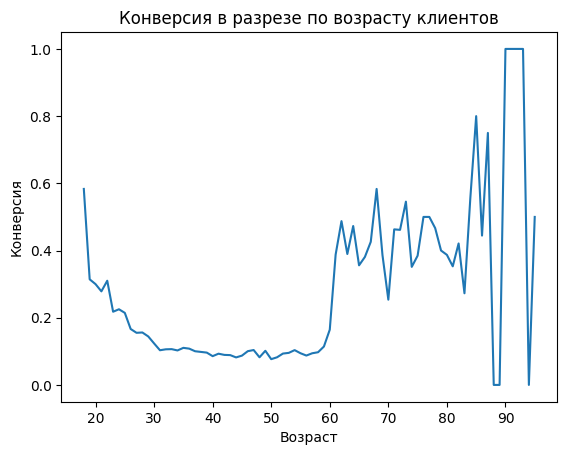

In [57]:
plt.plot(df.groupby('age')['is_deposit'].mean().index, df.groupby('age')['is_deposit'].mean().values)
plt.title('Конверсия в разрезе по возрасту клиентов')
plt.xlabel('Возраст')
plt.ylabel('Конверсия')
plt.show()

Тут интересные факты вырисовываются:
- в +-20 лет хорошая конверсия, которая потом падает
- начиная с 60 конверсия возращается к значемниям в 20 лет
- около 90 лет люди все оформляют депозит (скорее всего, мало наблюдений)

То есть молодежь и пенсионеры охотнее открывают депозиты, чем люди среднего возраста

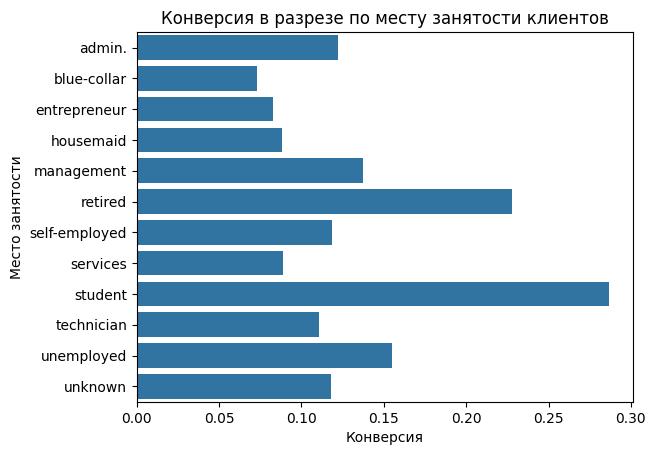

In [61]:
sns.barplot(y=df.groupby('job')['is_deposit'].mean().index, x=df.groupby('job')['is_deposit'].mean().values)
plt.title('Конверсия в разрезе по месту занятости клиентов')
plt.xlabel('Конверсия')
plt.ylabel('Место занятости')
plt.show()

- Как раз у той самой молодежи (студентов) как раз самая высокая конверсия
- и также не отстает значение конверсии от пенсионеров (что подтверждает предыдущий график)

Но при этом у этих двух групп не такой высокий процент (25-30%), в то время как у молодежи и пенсионеров (по возрасту) достигались значения 60% и больше

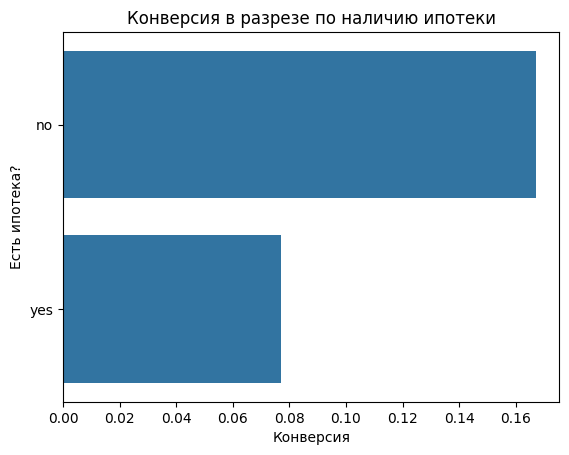

In [86]:
sns.barplot(y=df.groupby('housing')['is_deposit'].mean().index, x=df.groupby('housing')['is_deposit'].mean().values)
plt.title('Конверсия в разрезе по наличию ипотеки')
plt.xlabel('Конверсия')
plt.ylabel('Есть ипотека?')
plt.show()

In [77]:
balance_housing=df.groupby('housing')['balance'].agg(['mean','median'])
balance_housing

,mean,median
housing,,
no,1596.501270,507.0
yes,1175.103064,412.0


<Axes: title={'center': 'Распределение статистик по балансу, в зависимости от того, открыл ли клиент депозитный счет по итогам РК'}>

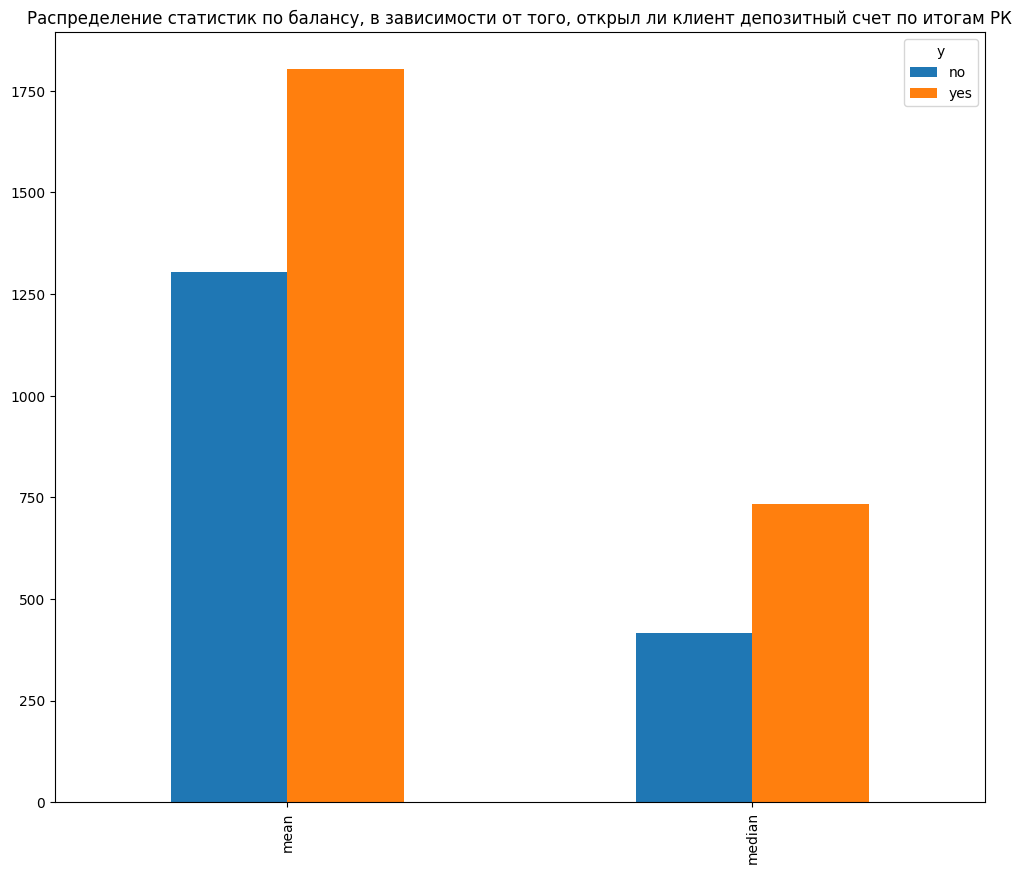

In [109]:
df.groupby('y').agg(
    mean=('balance', 'mean'),
    median=('balance', 'median')
).T.plot(kind='bar', title='Распределение статистик по балансу, в зависимости от того, открыл ли клиент депозитный счет по итогам РК', figsize=(12, 10))

In [85]:
print(f'Абсолютная  разница для медианы = {balance_housing.iloc[0,1]-balance_housing.iloc[1,1]} евро')
print(f'Абсолютная разница для среднего = {round(balance_housing.iloc[0,0]-balance_housing.iloc[1,0],2)} евро')

print(f'Относительная разница для медианы = {round((balance_housing.iloc[0,1]-balance_housing.iloc[1,1])/balance_housing.iloc[0,1]*100, 2)} %')
print(f'Относительная разница для среднего = {round((balance_housing.iloc[0,0]-balance_housing.iloc[1,0])/balance_housing.iloc[0,0]*100, 2)} %')

Абсолютная  разница для медианы = 95.0 евро
Абсолютная разница для среднего = 421.4 евро
Относительная разница для медианы = 18.74 %
Относительная разница для среднего = 26.4 %


In [89]:
df['balance'].mean(), df['balance'].median()

(np.float64(1362.2720576850766), np.float64(448.0))

У нас среднее сильно больше медианы -> следовательно по данному признаку у нас есть выбросы, а следовательно мы бужем рассматривать медиану, как устойчивый инструмент к выбросам

### Гипотеза 1

Кажется, что чаще открывают депозит люди с большим количеством денег на балансе. Давайте попробуем сделать это утверждение статзначимым. \
Сформулируем гипотезу явно: \
\
$H_0$: Среднее значение баланса клиентов, открывших депозит, равно среднему значению баланса клиентов не открывших депозит \
$H_1$: Среднее значение баланса клиентов, открывших депозит, больше среднего значения баланса клиентов не открывших депозит

Далее, выбор теста. Исходя из семинарский таблички видим следующий выбор. Наши данные числовые, у нас две группы (выборки не связаны), распределение визуально не нормальное, но нужно это проверить. Воспользуемся QQ-plot, критерий Шапиро подходит для выборок <5к записей.

In [110]:
X_0 = df[df['y'] == 'no']['balance']
X_1 = df[df['y'] == 'yes']['balance']

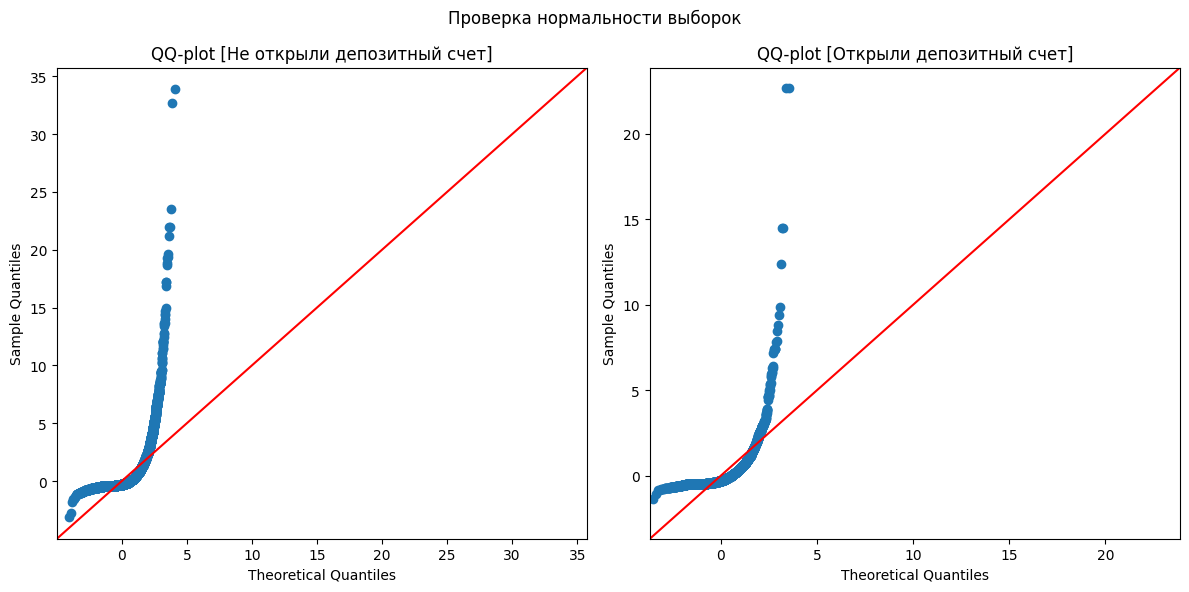

In [113]:
from statsmodels.api import qqplot
from scipy.stats import norm

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

qqplot(X_0, norm, line='45', fit=True, ax=axs[0])
axs[0].set_title('QQ-plot [Не открыли депозитный счет]')
qqplot(X_1, norm, line='45', fit=True, ax=axs[1])
axs[1].set_title('QQ-plot [Открыли депозитный счет]')
fig.suptitle('Проверка нормальности выборок')

plt.tight_layout()

Как мы видим из построенных QQ-plot'ов выборки действительно не нормальные, но идентичные между собой, значит предварительно можно воспользоваться тестом Манна-Уитни. Закрепим, что:
1. Данные распределены идентично — верно, видим из QQ-plot
2. [Выборки независимы](https://statpsy.ru/mana-uitni/u-manna-uitni/#:~:text=%D0%A1%D1%80%D0%B0%D0%B2%D0%BD%D0%B8%D0%B2%D0%B0%D0%B5%D0%BC%D1%8B%D0%B5%20%D0%B7%D0%BD%D0%B0%D1%87%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%BD%D0%B5,%D1%81%D0%BE%D0%BE%D1%82%D0%B2%D0%B5%D1%82%D1%81%D1%82%D0%B2%D0%BE%D0%B2%D0%B0%D1%82%D1%8C%20%D0%BD%D0%BE%D1%80%D0%BC%D0%B0%D0%BB%D1%8C%D0%BD%D0%BE%D0%BC%D1%83%20%D1%80%D0%B0%D1%81%D0%BF%D1%80%D0%B5%D0%B4%D0%B5%D0%BB%D0%B5%D0%BD%D0%B8%D1%8E)
3. n >> , можем не проверять ранжируемость, у нас она очевидно выполняется.

Для нас все ок, применяем

In [114]:
from scipy.stats import mannwhitneyu

statistic, pvalue = mannwhitneyu(X_0, X_1, alternative='less') # less X_0 < X_1 (те, кто не открыл < те, кто открыл)

statistic, pvalue

(np.float64(86557474.5), np.float64(3.2969229043447577e-101))

Заметим, что p_value << 0.01 --> Можем отвергнуть гипотезу с очень большой уверенностью. \
Сделаем стат. значимое утверждение: Клиенты с более высоким балансом чаще открывают депозитный счет (оно в целом и логично). Совет для компании — первично прозванивать клиентов с более высоким балансом.

Далее проверим нашу гипотезу более сильным методом — bootstrap. Подронбее о нем [тут](https://habr.com/ru/companies/X5Tech/articles/679842/) \
Предлагается:
1. Засэмплить (с возвращением) много раз распределение X_0 и X_1
2. Посчитать разницу средних X_1 и X_0
3. Посмотреть распределние X_1 и X_0
4. Взять 95 двухсторонний перцентиль и посмотреть, где лежит наша величина, всегда ли она будет положительной (чтобы сказать что у клиентов с открытым кредитом баланс выше, чем у клиентов с неоткрытым)
Для реализации идеи воспользуемся также scipy stats, тут можно передать в качестве [стаистики как раз интересуюущую нас разницу средних](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html#:~:text=def%20my_statistic(sample1%2C%20sample2%2C%20axis%3D%2D1)%3A%0A...)

In [115]:
from scipy.stats import bootstrap

def my_statistic(sample1, sample2, axis=-1):
    mean1 = np.mean(sample1, axis=axis)
    mean2 = np.mean(sample2, axis=axis)
    return mean1 - mean2

res = bootstrap((X_1, X_0), my_statistic, n_resamples=10000, alternative='two-sided', confidence_level=0.95, method='BCa') # Скорректированное смещение и ускоренный, проверяет в каком проценте статистика меньше исходной статистики и если меньше 50%, то сдвигает перцентили — идеально для нашего кривого распределения

In [116]:
res.confidence_interval

ConfidenceInterval(low=np.float64(407.26867425945613), high=np.float64(606.8918114735245))

В доверительный интервал попали значения [409, 606]. То есть с 95% вероятностью дельта балансов между теми, кто открыл счет и не открыл попадает в этот промежуток. В промежутке нет значений, меньше нуля, значит опять же — исходная гипотеза верна. Stonks!!

Бизнес-вывод: стоит больше внимания уделять клиентам с большим балансом, ведь они чаще открывают депозит, то есть именно на таких людей должны быть направлены в первую очередь целевые звонки маркетинговой кампании - повысит конверсию и сократит затраты на обзовн.

### Гипотеза 2

<Axes: >

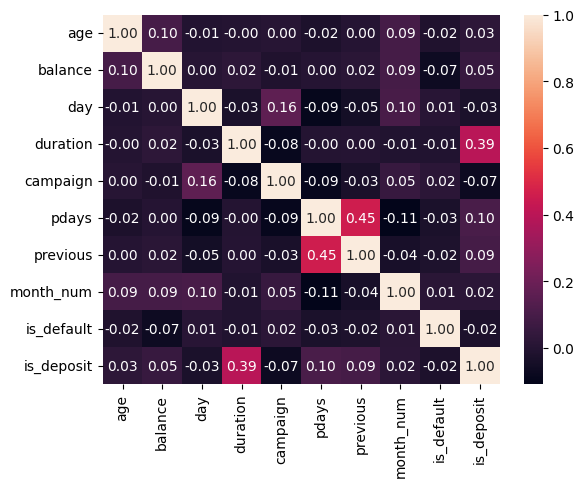

In [98]:
sns.heatmap(df.corr(numeric_only=True),annot=True, fmt='.2f')

То есть мы наблюдаем различие в среднем балансе относительно наличия ипотеки, что в принципе логично, так как ипотека отягощает и уводит лишние средства со счетов, поэтому клиентам с ипотекой сложнее открыть депозит (им бы с ипотекой разобраться). Мы можем сказать, что финансовое положение - основа для оформления депозита. Исходя из всего сказанного можно сделать вывод (и в принципе это логично), что оформление депозита зависит от баланса. Однако у нас не выявлено линейной корреляции между балансом и оформлением депозита (слабая связь на хитмапе). Плюс мы посмотрели на статзначимую разницу в балансе у открывших и неоткрывших депозит (целевая переменная).


А также мы увидели, что неплохой задел для анализа открыл для нас параметр возраста - достаточно интересно посмотреть на сравнение двух возрастных групп (пенсионеры и непенсионеры). Поэтому следующие визуализации посвятим рассмотрению влияния возраста и баланса друг на друга.

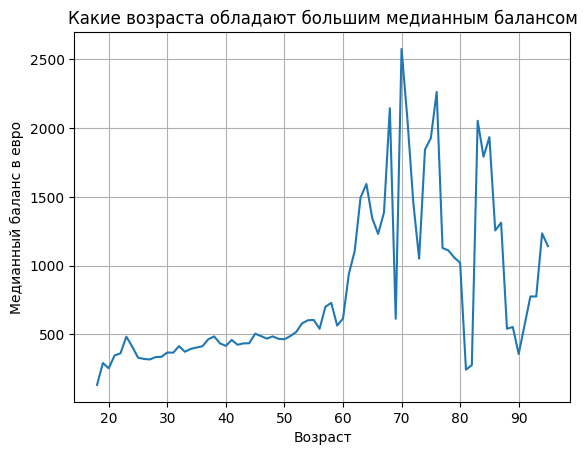

In [102]:
plt.plot(df.groupby('age')['balance'].median().index, df.groupby('age')['balance'].median().values)
plt.title('Какие возраста обладают большим медианным балансом')
plt.xlabel('Возраст')
plt.ylabel('Медианный баланс в евро')
plt.grid()
plt.show()

- до 60 лет баланс низкий, однако имеет тенденцию к росту (люди по мере жизни накапливают все больше денег)
- после 60 (где-то в 62) начинается резкий бум (практически в 3 раза)
- но также начинаются сильные колебания (но это из-за малого количества наблюдений в датасете - из графика по распределению возраста)

В целом прослеживается зависимость, что с возрастом увеличивается количество денег на балансе.

Из этого можно сформировать гипотезу:

**Между балансом и возрастом существует положительная связь**

Проверим это через доступные статистические методы - для этого лучшего всего подойдет корреляционный анализ.

H0: между балансом и возрастом корреляция равна 0 (независимые признаки) \
H1: между балансом и возрастом есть положительная корреляция\
уровень значимости: 0.05

Будем использовать тест Спирмена, так как:
- линейную связь мы проверили - ее нет
- оба признака - числовые
- распределения признаков не нормальные 

In [151]:
stats.spearmanr(df['age'], df['balance'])

SignificanceResult(statistic=np.float64(0.096380304771986), pvalue=np.float64(9.361066305377324e-94))

Имеем, что наш pvalue<alpha и следовательно мы отвергаем H0.

Но у нас получился слишком маленький коэффициент корреляции = 0.09, что может только говорить о том, что между балансом и возрастом действительно есть связь положительная, но она очень слабая.

ТО есть визуальные различия были обманчивы и мы не можем сильно полагаться на возраст в оценке баланса.

Вывод: не стоит строить маркетинговую кампанию вокруг только возраста - внутри каждой возрастной группы слишком большой разброс балансов (либо у нас слишком небольшое количество записей по пенсионерам). Следует учитывать и другие факторы - например, ипотеку или профессию, для которых мы тоже строили графики и находили интересные визуальные зависимости.

### Гипотеза 3

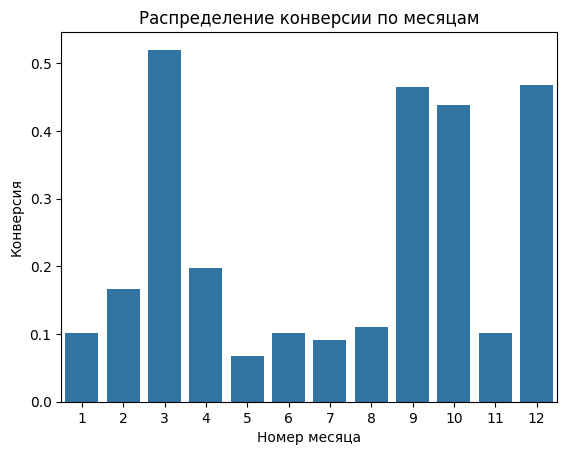

In [115]:
sns.barplot(data=df.groupby('month_num')['is_deposit'].mean().reset_index(),x='month_num',y='is_deposit')
plt.title('Распределение конверсии по месяцам')
plt.xlabel('Номер месяца')
plt.ylabel('Конверсия')
plt.show()

Сразу можно выделить 4 месяца с высокими значениями конверсии - март, сентябрь, октябрь и декабрь.

Однако стоит еще проверить, насколько вообще значимы эти отличия в плане количества звонков в принципе по месяцам - может, в январе просто мало обзванивали

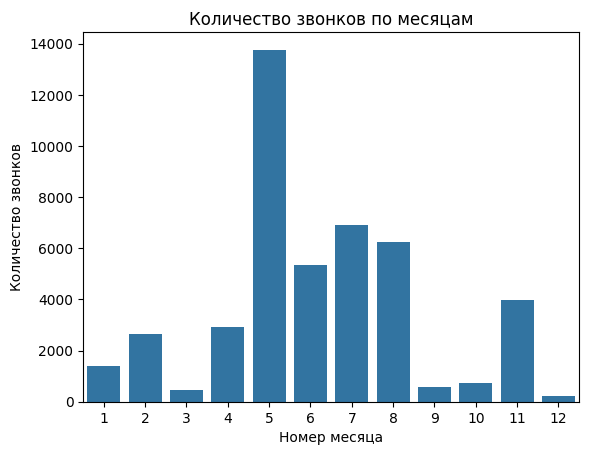

In [118]:
sns.barplot(data=df.groupby('month_num')['is_deposit'].count().reset_index(),x='month_num',y='is_deposit')
plt.title('Количество звонков по месяцам')
plt.xlabel('Номер месяца')
plt.ylabel('Количество звонков')
plt.show()

Тут нас и поджидает проблема - в месяца с низкой конверсией в принципе было малое количество звонков совершено, а, например, в мае очень много (14000 - это почти в 7 РАЗ больше, чем в январе)

In [142]:
month_deposit = df.groupby('month_num')['is_deposit'].agg(['sum','mean','count']).rename(columns={'sum':'Оформленные депозиты',
                                                                                  'count':'Количество звонков',
                                                                                  'mean':'Конверсия'})
month_deposit

,Оформленные депозиты,Конверсия,Количество звонков
month_num,,,
1,142,0.101212,1403
2,441,0.166478,2649
3,248,0.519916,477
4,577,0.196794,2932
5,925,0.067195,13766
6,546,0.102228,5341
7,627,0.090935,6895
8,688,0.110133,6247
9,269,0.464594,579


Ключевое наблюдения из этой сводной таблицы:
- при маленьком количестве звонков получается большая конверсия (март,декабрь,сентябрь,октябрь)
- при большом количестве звонков получается маленькая конверсия (май, июль, август)

То есть компания слишком много сливает деньги на обзвоны, которые приносят малую конверсию.

Непонятно только, почему банк в какие-то месяцы направляет звонков больше. Возможно, они пытаются конкретно в эти месяцы выловить "золотых рыбок", у которых много денег на балансе, то есть которые больше денежного потока привнесут компании. Посмотрим на это:

In [146]:
golden_fishes=pd.merge(month_deposit, df.groupby('month_num')['balance'].agg(['max','median']), on='month_num')
golden_fishes

,Оформленные депозиты,Конверсия,Количество звонков,max,median
month_num,,,,,
1,142,0.101212,1403,19833,433.0
2,441,0.166478,2649,52587,503.0
3,248,0.519916,477,32685,997.0
4,577,0.196794,2932,81204,642.5
5,925,0.067195,13766,58544,337.0
6,546,0.102228,5341,102127,625.0
7,627,0.090935,6895,58932,244.0
8,688,0.110133,6247,66721,418.0
9,269,0.464594,579,59649,889.0


In [149]:
golden_fishes.idxmin(axis=0)

Оформленные депозиты    12
Конверсия                5
Количество звонков      12
max                      1
median                   7
dtype: int64

In [150]:
golden_fishes.idxmax(axis=0)

Оформленные депозиты     5
Конверсия                3
Количество звонков       5
max                      6
median                  11
dtype: int64

Предположение про "золотых рыбок" не подтвердилось - в мае (месяце с самым большим числом звонков) один из самых низких показателей медианы баланса, а в марте, сентябре, октябре и декабре (месяца с малым кол-вом звонков, но высокой конверсией) медианный баланс значительно выше

Тема с месяцами нестабильна и не до конца понятна. Поэтому стоит выдвинуть гипотезу о том, что открытие депозита зависит от месяца (когда компания позвонила клиенту).

H0: открытие депозита не зависит от месяца \
H1: открытие депозита зависит от месяца \
уровень значимости = 0.05

Как статистический тест для проверки возьмем [Хи-квадрат](https://en.wikipedia.org/wiki/Chi-squared_test), потому что:
- у нас два категориальных признака
- все наблюдения (в датасете все пользователи уникальны) независимы
- ожидаемая частота не менее 5 (в самом плохом по количеству звонков месяце, декабре, было 214)

документация: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html

In [155]:
from scipy.stats import chi2_contingency

chi,pvalue,dimensions,_=chi2_contingency(pd.crosstab(df['is_deposit'],df['month_num']))
print(chi)
print(pvalue)
print(dimensions)

3061.8389384452685
0.0
11


pvalue получился меньше уровня значимости, следовательно мы отвергаем нулевую гипотезу, а следовательно открытие депозита в определенный месяц значимо (зависимоть между месяцем и целевой переменной)

Для сравнения проведем еще один стат тест. Можно было бы взять Манн-Уитни (независимость данных + порядковый признак месяца), но он только для двух групп, а у нас их 12. Тогда можно было бы дисперсионный анализ взять, однако наше распределние оформления депозита ненормально. Остается только Краскел-Уоллис (непараметричсекий тест на больше 3 групп).

Условия применимости теста [Краскел-Уоллиса](https://en.wikipedia.org/wiki/Kruskal–Wallis_test):
- порядковый признак - месяц
- независимые выборки по месяцам
- независимые записи внутри каждого месяца
- выполняется требование о минимум 5 записях

документация: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html

Все те же гипотезы и уровень значимости:

In [157]:
from scipy.stats import kruskal
kruskal(*(df[df['month_num']==i]['is_deposit'].values for i in range(1,13)))

KruskalResult(statistic=np.float64(3061.771215127053), pvalue=np.float64(0.0))

pvalue получился меньше уровня значимости, следовательно мы отвергаем нулевую гипотезу, а следовательно открытие депозита в определенный месяц значимо (зависимоть между месяцем и целевой переменной)

Оба метода отвергают нулевую гипотезу, а также у них очень близкие значения, хотя имеют разную природу, что говорит нам о стабильности получаемого результата - между месяцем и открытием депозита есть зависимость

Бизнес-вывод: банку стоит присмотреться к месяцам, в которые совершаются звонки, ведь они сильно влияют на конверсию, что влияет на выручку. По представленным данным стоит ориентироваться на март, сентябрь, октябрь и декабрь (но стоит на большее количество исторических данных посмотреть). А, вот, для таких месяцев, как май, июль и август, необходимо пересмотреть распределение бюджета (много звонков-много денег тратим - маленькая конверсия). Возможно стоит перераспределить эти деньги как раз на "сильные" месяцы (март, сентябрь, октябрь и декабрь)